In [3]:
import pandas as pd
df=pd.read_csv("E:/Luminar/Machine_Learning/World_cup_prediction_model/International football results/results.csv")


In [4]:
df[df['tournament']=='FIFA World Cup']

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
1490,1930-07-13,Belgium,United States,0.0,3.0,FIFA World Cup,Montevideo,Uruguay,True
1491,1930-07-13,France,Mexico,4.0,1.0,FIFA World Cup,Montevideo,Uruguay,True
1492,1930-07-14,Brazil,Yugoslavia,1.0,2.0,FIFA World Cup,Montevideo,Uruguay,True
1493,1930-07-14,Peru,Romania,1.0,3.0,FIFA World Cup,Montevideo,Uruguay,True
1494,1930-07-15,Argentina,France,1.0,0.0,FIFA World Cup,Montevideo,Uruguay,True
...,...,...,...,...,...,...,...,...,...
49472,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True
49473,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49474,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49475,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True


In [5]:
df["date"].min(),df["date"].max()
# df.isna().sum()

('1872-11-30', '2026-06-27')

In [6]:
df[df["home_score"].isna()]

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49409,2026-06-13,Qatar,Switzerland,NaN,NaN,FIFA World Cup,Santa Clara,United States,True
49410,2026-06-13,Brazil,Morocco,NaN,NaN,FIFA World Cup,East Rutherford,United States,True
49411,2026-06-13,Haiti,Scotland,NaN,NaN,FIFA World Cup,Foxborough,United States,True
49412,2026-06-13,Australia,Turkey,NaN,NaN,FIFA World Cup,Vancouver,Canada,True
49413,2026-06-14,Germany,Curaçao,NaN,NaN,FIFA World Cup,Houston,United States,True
...,...,...,...,...,...,...,...,...,...
49472,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True
49473,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49474,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49475,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True


In [7]:
def get_result(row):
    if row['home_score']>row['away_score']:
        return "H"#home
    elif row['home_score']<row['away_score']:
        return "A"#away
    else:
        return "D"#draw
df['result'] = df.apply(get_result, axis=1)
df['result'].value_counts()
# df.iloc[1655:1700]

result
H    24215
A    13960
D    11302
Name: count, dtype: int64

In [71]:
df['country'].nunique()

269

In [9]:
df["goal_difference"]=df["home_score"]-df["away_score"]
df["date"].dtype
df['date']=pd.to_datetime(df['date'])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

In [10]:
historical_df=df[df['home_score'].notna()].copy()
upcoming_df=df[df['home_score'].isna()].copy()

historical_df=historical_df[historical_df['date']>='2000-01-01']

In [11]:
print("Historical matches:", historical_df.shape)
print("Upcoming WC matches:", upcoming_df.shape)

Historical matches: (25347, 13)
Upcoming WC matches: (68, 13)


In [61]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# india=df[((df['home_team']=='India')|(df['away_team']=='India') & (df['home_score'].notna()))].copy()
# def india_result(row):
#     if row['home_team']=='India':
#         if row['home_score']>row['away_score']:
#             return "Win"
#         elif row['home_score']<row['away_score']:
#             return "Loss"
#         else: return "Draw"
#     else:
#         if row['away_score']>row['home_score']:
#             return "Win"
#         elif row['away_score']<row['home_score']:
#             return "Loss"
#         else: return "Draw"

# india["India_result"]=india.apply(india_result,axis=1)
# print("Total India Matches:",len(india))
# print(india['India_result'].value_counts())


In [13]:
# plt.figure(figsize=(8,5))
# counts = india['India_result'].value_counts()
# counts = counts.reindex(['Win', 'Loss', 'Draw'])
# colors=['green','red','gray']
# counts.plot(kind='bar',color=colors)
# plt.title("Indian Football Results all time")
# plt.xlabel("Result")
# plt.ylabel("Number of Matches")
# plt.xticks(rotation=0)
# plt.tight_layout()
# plt.show()

In [14]:

# india['year'] = india['date'].dt.year

# yearly = india.groupby(['year', 'India_result']).size().unstack(fill_value=0)
# yearly.plot(kind='bar', figsize=(15, 5), color=['gray', 'red', 'green'])

# plt.title("India Football Results Year by Year")
# plt.xlabel("Year")
# plt.ylabel("Number of Matches")
# plt.legend(title="Result")
# plt.tight_layout()
# plt.show()

In [15]:
print(historical_df.shape)
print(upcoming_df.shape)

(25347, 13)
(68, 13)


In [16]:
historical_df=historical_df.sort_values("date").reset_index(drop=True)
historical_df.index

RangeIndex(start=0, stop=25347, step=1)

In [17]:
def get_team_form(team,date,df,n=10):
    past=df[(((df['home_team']==team) | (df['away_team']==team)))&(df['date']<date)].tail(n)
    if len(past)==0:
        return 0,0,0
    goal_scored=[]
    goal_conceded=[]
    wins=[]
    for _,row in past.iterrows():
        if row['home_team']==team:
            goal_scored.append(row['home_score'])
            goal_conceded.append(row['away_score'])
            wins.append(1 if row['result']=='H' else 0)
        else:
            goal_scored.append(row['away_score'])
            goal_conceded.append(row['home_score'])
            wins.append(1 if row['result']=='A' else 0)
    return round(sum(goal_scored)/len(goal_scored),2),\
           round(sum(goal_conceded)/len(goal_conceded),2),\
           round(sum(wins)/len(wins),2) 

In [18]:
avg_goal_scored,avg_goal_concided,win_rate=get_team_form(team="Brazil",date=pd.Timestamp('2026-04-01'),df=historical_df)
print("Average_Goal_Scored:",avg_goal_scored)
print("Average_Goal_Conceded:",avg_goal_concided)
print("Win Rate:",win_rate)


Average_Goal_Scored: 1.8
Average_Goal_Conceded: 0.8
Win Rate: 0.5


In [19]:
home_scored=[]
home_conceded=[]
home_win_rate=[]
away_scored=[]
away_conceded=[]
away_win_rate=[]

for idx,row in historical_df.iterrows():# idx catches the index number but we don't use it, only row matters
    hs,hc,hw=get_team_form(row["home_team"],row['date'],historical_df)
    as_,ac,aw=get_team_form(row["away_team"],row['date'],historical_df)
    home_scored.append(hs)
    home_conceded.append(hc)
    home_win_rate.append(hw)
    away_scored.append(as_)
    away_conceded.append(ac)
    away_win_rate.append(aw)

historical_df['home_scored']=home_scored
historical_df['home_conceded']=home_conceded
historical_df['home_win_rate']=home_win_rate
historical_df['away_scored']=away_scored
historical_df['away_conceded']=away_conceded
historical_df['away_win_rate']=away_win_rate










In [20]:
historical_df['neutral'] = historical_df['neutral'].astype(int)
historical_df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,goal_difference,year,month,home_scored,home_conceded,home_win_rate,away_scored,away_conceded,away_win_rate
0,2000-01-04,Egypt,Togo,2.0,1.0,Friendly,Aswan,Egypt,0,H,1.0,2000,1,0.0,0.0,0.0,0.0,0.0,0.0
1,2000-01-07,Tunisia,Togo,7.0,0.0,Friendly,Tunis,Tunisia,0,H,7.0,2000,1,0.0,0.0,0.0,1.0,2.0,0.0
2,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,Friendly,Port of Spain,Trinidad and Tobago,0,D,0.0,2000,1,0.0,0.0,0.0,0.0,0.0,0.0
3,2000-01-09,Burkina Faso,Gabon,1.0,1.0,Friendly,Ouagadougou,Burkina Faso,0,D,0.0,2000,1,0.0,0.0,0.0,0.0,0.0,0.0
4,2000-01-09,Guatemala,Armenia,1.0,1.0,Friendly,Los Angeles,United States,1,D,0.0,2000,1,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
features=['home_scored','home_conceded','home_win_rate','away_scored','away_conceded','away_win_rate','neutral']
X=historical_df[features]
y=historical_df["result"]
print(X.shape)
print(y.shape)
historical_df = historical_df.drop(columns=['city', 'country', 'year', 'month'])
y.value_counts()

(25347, 7)
(25347,)


result
H    12205
A     7238
D     5904
Name: count, dtype: int64

In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape[0])
print(X_test.shape[0])

20277
5070


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

models={"Logistic Regression":LogisticRegression(max_iter=1000),
"Naive Bayes":GaussianNB(),
"KNN":KNeighborsClassifier(),
"Random Forest":RandomForestClassifier(n_estimators=99)
}

for name,model in models.items():
    model.fit(X_train,y_train)
    score=model.score(X_test,y_test)
    print(f"{name}:{round(score*100,2)}%")

Logistic Regression:54.1%
Naive Bayes:51.22%
KNN:45.27%
Random Forest:50.06%


In [24]:
lr_model=LogisticRegression(max_iter=1000)
lr_model.fit(X_train,y_train)
lr_model.score(X_test,y_test)*100

54.1025641025641

In [25]:
#Add more features
tournament_weight = {
    'Friendly': 1,
    'FIFA World Cup qualification': 3,
    'UEFA Euro qualification': 3,
    'Africa Cup of Nations qualification': 3,
    'Copa América': 4,
    'UEFA Euro': 4,
    'Africa Cup of Nations': 4,
    'FIFA World Cup': 5
}
historical_df["tournament_weight"]=historical_df['tournament'].map(tournament_weight).fillna(2)
historical_df["tournament_weight"].value_counts()
historical_df

,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,home_scored,home_conceded,home_win_rate,away_scored,away_conceded,away_win_rate,tournament_weight
0,2000-01-04,Egypt,Togo,2.0,1.0,Friendly,0,H,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2000-01-07,Tunisia,Togo,7.0,0.0,Friendly,0,H,7.0,0.0,0.0,0.0,1.0,2.0,0.0,1.0
2,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,Friendly,0,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2000-01-09,Burkina Faso,Gabon,1.0,1.0,Friendly,0,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2000-01-09,Guatemala,Armenia,1.0,1.0,Friendly,1,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25342,2026-06-10,Afghanistan,Pakistan,0.0,2.0,Diamond Jubilee International Football Tournament,1,A,-2.0,0.4,1.4,0.1,0.6,2.2,0.2,2.0
25343,2026-06-11,Mexico,South Africa,2.0,0.0,FIFA World Cup,0,H,2.0,1.6,0.4,0.6,1.5,1.0,0.5,5.0
25344,2026-06-11,South Korea,Czech Republic,2.0,1.0,FIFA World Cup,1,H,1.0,1.5,1.2,0.6,2.2,0.9,0.5,5.0
25345,2026-06-12,Canada,Bosnia and Herzegovina,1.0,1.0,FIFA World Cup,0,D,0.0,1.1,0.4,0.4,2.0,1.0,0.3,5.0


In [26]:
#Build Head To Head
def get_h2h(home_team, away_team, date, df):
    c1 = (df['home_team']==home_team) & (df['away_team']==away_team)
    c2 = (df['home_team']==away_team) & (df['away_team']==home_team)
    past = df[(c1 | c2) & (df['date'] < date)]
    
    if len(past)==0:
        return 0, 0, 0
    home_wins=0
    away_wins=0
    draws=0
    for _,row in past.iterrows():
        if row['result']=="D":
            draws+=1
        elif row["result"]=="H":
            if row["home_team"]==home_team:
                home_wins+=1
            else:
                away_wins+=1
        elif row["result"]=="A":
            if row["away_team"]==home_team:
                home_wins+=1
            else:
                away_wins+=1
    

    
    return home_wins, away_wins, draws


In [74]:
# brazil,argentina,draw=get_h2h(home_team="England",away_team="Argentina",date=pd.Timestamp('2026-04-01'),df=df)
# print("Brazil Won:",brazil)
# print("Argentina Won:",argentina)
# print("Draws:",draw)


In [28]:
# # Drop old buggy columns
# historical_df = historical_df.drop(columns=['h2h_home_wins', 'h2h_away_wins', 'h2h_draws'])

# Rerun loop with fixed function
h2h_home_wins = []
h2h_away_wins = []
h2h_draws = []

for idx, row in historical_df.iterrows():
    hw, aw, d = get_h2h(row['home_team'], row['away_team'], row['date'], historical_df)
    h2h_home_wins.append(hw)
    h2h_away_wins.append(aw)
    h2h_draws.append(d)

historical_df['h2h_home_wins'] = h2h_home_wins
historical_df['h2h_away_wins'] = h2h_away_wins
historical_df['h2h_draws'] = h2h_draws

historical_df.tail()

,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,home_scored,home_conceded,home_win_rate,away_scored,away_conceded,away_win_rate,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws
25342,2026-06-10,Afghanistan,Pakistan,0.0,2.0,Diamond Jubilee International Football Tournament,1,A,-2.0,0.4,1.4,0.1,0.6,2.2,0.2,2.0,1,4,2
25343,2026-06-11,Mexico,South Africa,2.0,0.0,FIFA World Cup,0,H,2.0,1.6,0.4,0.6,1.5,1.0,0.5,5.0,1,1,1
25344,2026-06-11,South Korea,Czech Republic,2.0,1.0,FIFA World Cup,1,H,1.0,1.5,1.2,0.6,2.2,0.9,0.5,5.0,1,1,0
25345,2026-06-12,Canada,Bosnia and Herzegovina,1.0,1.0,FIFA World Cup,0,D,0.0,1.1,0.4,0.4,2.0,1.0,0.3,5.0,0,0,0
25346,2026-06-12,United States,Paraguay,4.0,1.0,FIFA World Cup,0,H,3.0,1.8,1.7,0.5,1.2,1.0,0.4,5.0,4,2,0


In [29]:
historical_df.tail()


,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,home_scored,home_conceded,home_win_rate,away_scored,away_conceded,away_win_rate,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws
25342,2026-06-10,Afghanistan,Pakistan,0.0,2.0,Diamond Jubilee International Football Tournament,1,A,-2.0,0.4,1.4,0.1,0.6,2.2,0.2,2.0,1,4,2
25343,2026-06-11,Mexico,South Africa,2.0,0.0,FIFA World Cup,0,H,2.0,1.6,0.4,0.6,1.5,1.0,0.5,5.0,1,1,1
25344,2026-06-11,South Korea,Czech Republic,2.0,1.0,FIFA World Cup,1,H,1.0,1.5,1.2,0.6,2.2,0.9,0.5,5.0,1,1,0
25345,2026-06-12,Canada,Bosnia and Herzegovina,1.0,1.0,FIFA World Cup,0,D,0.0,1.1,0.4,0.4,2.0,1.0,0.3,5.0,0,0,0
25346,2026-06-12,United States,Paraguay,4.0,1.0,FIFA World Cup,0,H,3.0,1.8,1.7,0.5,1.2,1.0,0.4,5.0,4,2,0


In [30]:
historical_df.head()

,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,home_scored,home_conceded,home_win_rate,away_scored,away_conceded,away_win_rate,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws
0,2000-01-04,Egypt,Togo,2.0,1.0,Friendly,0,H,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0
1,2000-01-07,Tunisia,Togo,7.0,0.0,Friendly,0,H,7.0,0.0,0.0,0.0,1.0,2.0,0.0,1.0,0,0,0
2,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,Friendly,0,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0
3,2000-01-09,Burkina Faso,Gabon,1.0,1.0,Friendly,0,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0
4,2000-01-09,Guatemala,Armenia,1.0,1.0,Friendly,1,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0


In [82]:
from sklearn.tree import DecisionTreeClassifier

features = [
    'home_scored', 'home_conceded', 'home_win_rate',
    'away_scored', 'away_conceded', 'away_win_rate',
    'neutral', 'tournament_weight',
    'h2h_home_wins', 'h2h_away_wins', 'h2h_draws'
]

X = historical_df[features]
y = historical_df['result']
split_date = '2022-01-01'
train = historical_df[historical_df['date'] < split_date]
test = historical_df[historical_df['date'] >= split_date]
X_train=train[features]
y_train=train["result"]
X_test=test[features]
y_test=test["result"]

lr_model = LogisticRegression(max_iter=1000)
nb_model = GaussianNB()
knn_model = KNeighborsClassifier(n_neighbors=5)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)

models = {
    'Logistic Regression': lr_model,
    'Naive Bayes': nb_model,
    'KNN': knn_model,
    'Random Forest': rf_model,
    'Decision Tree': dt_model
}

for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"{name}: {round(score*100, 2)}%")

Logistic Regression: 55.97%
Naive Bayes: 52.78%
KNN: 47.42%
Random Forest: 54.68%
Decision Tree: 42.41%


In [83]:
def calculate_elo(df, k=32, initial=1000):
    elo = {}
    elo_home = []
    elo_away = []
    for _, row in df.iterrows():
        home = row["home_team"]
        away = row["away_team"]

        home_elo = elo.get(home, initial)
        away_elo = elo.get(away, initial)

        elo_home.append(home_elo)
        elo_away.append(away_elo)

        expected_home = 1 / (1 + 10**((away_elo - home_elo)/400))
        expected_away = 1 - expected_home

        if row['result'] == 'H':
            actual_home, actual_away = 1, 0
        elif row['result'] == "A":
            actual_home, actual_away = 0, 1
        else:
            actual_home, actual_away = 0.5, 0.5

        # ← ADD THIS BLOCK HERE
        goal_diff = abs(row['home_score'] - row['away_score'])
        if goal_diff == 1:
            k_adjusted = k
        elif goal_diff == 2:
            k_adjusted = k * 1.25
        else:
            k_adjusted = k * 1.5

        # update rating using k_adjusted instead of k
        elo[home] = home_elo + k_adjusted * (actual_home - expected_home)
        elo[away] = away_elo + k_adjusted * (actual_away - expected_away)

    df['elo_home'] = elo_home
    df['elo_away'] = elo_away
    return df, elo


In [84]:

historical_df,final_elo=calculate_elo(historical_df)
historical_df['elo_diff'] = historical_df['elo_home'] - historical_df['elo_away']
print(f"\nTop 10 teams by Elo rating:")
sorted_elo=sorted(final_elo.items(),key=lambda x:x[1],reverse=True)
for team,rating in sorted_elo[:10]:
    print(f"{team}:{round(rating)}")


Top 10 teams by Elo rating:
Argentina:1555
Spain:1532
France:1476
Portugal:1451
Brazil:1449
England:1447
Colombia:1442
Germany:1437
Japan:1434
Morocco:1426


In [85]:
print(final_elo["Argentina"])

1555.332610428662


In [86]:
features = [
    'home_scored', 'home_conceded', 'home_win_rate',
    'away_scored', 'away_conceded', 'away_win_rate',
    'neutral', 'tournament_weight',
    'h2h_home_wins', 'h2h_away_wins', 'h2h_draws',
    'elo_home', 'elo_away','elo_diff'
]

X = historical_df[features]
y = historical_df['result']
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=train[features]
y_train=train["result"]
X_test=test[features]
y_test=test["result"]
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# lr_model.fit(X_train_scaled, y_train)
# for name, model in models.items():
#     model.fit(X_train, y_train)
#     score = model.score(X_test, y_test)
#     print(f"{name}: {round(score*100, 2)}%")

In [87]:


lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train_scaled, y_train)
print(f"Logistic Regression scaled: {round(lr_model.score(X_test_scaled, y_test)*100, 2)}%")

Logistic Regression scaled: 60.19%


In [88]:
home_scored=[]
home_conceded=[]
home_win_rate=[]
away_scored=[]
away_conceded=[]
away_win_rate=[]
h2h_home_wins=[]
h2h_away_wins=[]
h2h_draws=[]

for idx, row in upcoming_df.iterrows():
    hs,hc,hw = get_team_form(row['home_team'], row['date'], historical_df)
    as_,ac,aw = get_team_form(row['away_team'], row['date'], historical_df)
    h2hw, h2haw, h2hd = get_h2h(row['home_team'], row['away_team'], row['date'], historical_df)
    
    home_scored.append(hs)
    home_conceded.append(hc)
    home_win_rate.append(hw)
    away_scored.append(as_)
    away_conceded.append(ac)
    away_win_rate.append(aw)
    h2h_home_wins.append(h2hw)
    h2h_away_wins.append(h2haw)
    h2h_draws.append(h2hd)

upcoming_df['home_scored'] = home_scored
upcoming_df['home_conceded'] = home_conceded
upcoming_df['home_win_rate'] = home_win_rate
upcoming_df['away_scored'] = away_scored
upcoming_df['away_conceded'] = away_conceded
upcoming_df['away_win_rate'] = away_win_rate
upcoming_df['h2h_home_wins'] = h2h_home_wins
upcoming_df['h2h_away_wins'] = h2h_away_wins
upcoming_df['h2h_draws'] = h2h_draws
upcoming_df['neutral'] = upcoming_df['neutral'].astype(int)
upcoming_df['tournament_weight'] = upcoming_df['tournament'].map(tournament_weight).fillna(2)
upcoming_df['elo_home'] = upcoming_df['home_team'].map(final_elo).fillna(1000)
upcoming_df['elo_away'] = upcoming_df['away_team'].map(final_elo).fillna(1000)
upcoming_df['elo_diff'] = upcoming_df['elo_home'] - upcoming_df['elo_away']


In [89]:
X_upcoming = upcoming_df[features]
X_upcoming_scaled = scaler.transform(X_upcoming)
predictions = lr_model.predict(X_upcoming_scaled)
upcoming_df['predicted_result'] = predictions
for _, row in upcoming_df.iterrows():
    home = row['home_team']
    away = row['away_team']
    pred = row['predicted_result']
    
    if pred == 'H':
        outcome = f"{home} wins"
    elif pred == 'A':
        outcome = f"{away} wins"
    else:
        outcome = "Draw"
    
    print(f"{home} vs {away}: {outcome}")

Qatar vs Switzerland: Switzerland wins
Brazil vs Morocco: Morocco wins
Haiti vs Scotland: Scotland wins
Australia vs Turkey: Turkey wins
Germany vs Curaçao: Germany wins
Ivory Coast vs Ecuador: Ecuador wins
Netherlands vs Japan: Japan wins
Sweden vs Tunisia: Sweden wins
Belgium vs Egypt: Belgium wins
Iran vs New Zealand: Iran wins
Spain vs Cape Verde: Spain wins
Saudi Arabia vs Uruguay: Uruguay wins
France vs Senegal: France wins
Iraq vs Norway: Norway wins
Argentina vs Algeria: Argentina wins
Austria vs Jordan: Austria wins
Portugal vs DR Congo: Portugal wins
Uzbekistan vs Colombia: Colombia wins
England vs Croatia: England wins
Ghana vs Panama: Panama wins
Czech Republic vs South Africa: Czech Republic wins
Mexico vs South Korea: Mexico wins
Switzerland vs Bosnia and Herzegovina: Switzerland wins
Canada vs Qatar: Canada wins
Scotland vs Morocco: Morocco wins
Brazil vs Haiti: Brazil wins
United States vs Australia: United States wins
Turkey vs Paraguay: Turkey wins
Germany vs Ivory Co

In [39]:
print(historical_df.columns.tolist())

['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'neutral', 'result', 'goal_difference', 'home_scored', 'home_conceded', 'home_win_rate', 'away_scored', 'away_conceded', 'away_win_rate', 'tournament_weight', 'h2h_home_wins', 'h2h_away_wins', 'h2h_draws', 'elo_home', 'elo_away', 'elo_diff']


In [90]:
from sklearn.metrics import classification_report

y_pred = lr_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           A       0.56      0.62      0.59      1338
           D       0.36      0.05      0.08      1048
           H       0.63      0.86      0.73      2186

    accuracy                           0.60      4572
   macro avg       0.52      0.51      0.47      4572
weighted avg       0.55      0.60      0.54      4572



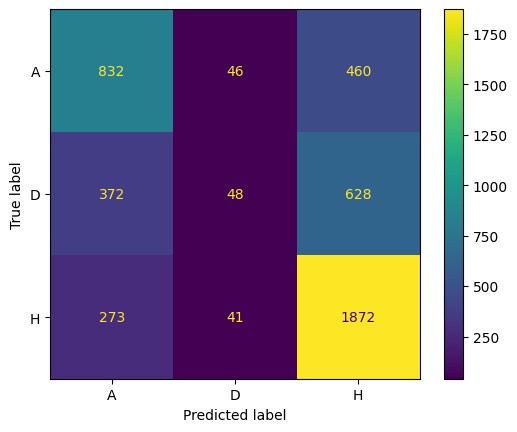

In [91]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [92]:
probs = lr_model.predict_proba(X_test_scaled)

print(lr_model.classes_)
print(probs[:10])

['A' 'D' 'H']
[[0.11543381 0.24561894 0.63894725]
 [0.43744844 0.36765939 0.19489217]
 [0.50837679 0.22686924 0.26475397]
 [0.27619221 0.32827508 0.39553271]
 [0.33994241 0.27005284 0.39000475]
 [0.16766741 0.26420361 0.56812898]
 [0.19263108 0.2956966  0.51167232]
 [0.18838604 0.31756789 0.49404607]
 [0.40793439 0.27717388 0.31489173]
 [0.07307039 0.16084625 0.76608336]]


In [43]:
import seaborn as sns

In [44]:
print(X_upcoming.shape)
print(scaler.feature_names_in_)


(68, 14)
['home_scored' 'home_conceded' 'home_win_rate' 'away_scored'
 'away_conceded' 'away_win_rate' 'neutral' 'tournament_weight'
 'h2h_home_wins' 'h2h_away_wins' 'h2h_draws' 'elo_home' 'elo_away'
 'elo_diff']


In [45]:
predictions

array(['A', 'A', 'A', 'A', 'H', 'A', 'A', 'H', 'H', 'H', 'H', 'A', 'H',
       'A', 'H', 'H', 'H', 'A', 'H', 'A', 'H', 'H', 'H', 'H', 'A', 'H',
       'H', 'H', 'H', 'H', 'H', 'A', 'H', 'A', 'H', 'H', 'H', 'H', 'H',
       'A', 'H', 'H', 'H', 'A', 'H', 'A', 'H', 'H', 'A', 'H', 'H', 'A',
       'A', 'A', 'H', 'A', 'A', 'A', 'A', 'A', 'A', 'H', 'H', 'A', 'A',
       'A', 'A', 'H'], dtype=object)

In [94]:
probabilities= lr_model.predict_proba(X_upcoming_scaled)
upcoming_df = upcoming_df.reset_index(drop=True)
for i,row in upcoming_df.iterrows():
    away_prob=probabilities[i][0]*100
    draw_prob=probabilities[i][1]*100
    home_prob=probabilities[i][2]*100
    print(f"{row["home_team"]} vs {row["away_team"]}")
    print(f"{row["home_team"]} Win: {home_prob:.2f}%")
    print(f"{row["away_team"]} Win: {away_prob:.2f}%")
    print(f"Draw: {draw_prob:.2f}%")
    print("-"*40)



Qatar vs Switzerland
Qatar Win: 7.02%
Switzerland Win: 80.20%
Draw: 12.78%
----------------------------------------
Brazil vs Morocco
Brazil Win: 37.35%
Morocco Win: 41.65%
Draw: 21.00%
----------------------------------------
Haiti vs Scotland
Haiti Win: 23.00%
Scotland Win: 57.23%
Draw: 19.77%
----------------------------------------
Australia vs Turkey
Australia Win: 32.55%
Turkey Win: 45.01%
Draw: 22.44%
----------------------------------------
Germany vs Curaçao
Germany Win: 86.63%
Curaçao Win: 4.43%
Draw: 8.95%
----------------------------------------
Ivory Coast vs Ecuador
Ivory Coast Win: 17.53%
Ecuador Win: 62.84%
Draw: 19.63%
----------------------------------------
Netherlands vs Japan
Netherlands Win: 35.76%
Japan Win: 40.82%
Draw: 23.42%
----------------------------------------
Sweden vs Tunisia
Sweden Win: 44.71%
Tunisia Win: 37.60%
Draw: 17.69%
----------------------------------------
Belgium vs Egypt
Belgium Win: 58.72%
Egypt Win: 23.18%
Draw: 18.10%
-------------------

In [97]:
actual_results = {
    # Matchday 1
    'Qatar vs Switzerland': 'D',
    'Brazil vs Morocco': 'D',
    'Haiti vs Scotland': 'A',
    'Australia vs Turkey': 'H',
    'Germany vs Curaçao': 'H',
    'Ivory Coast vs Ecuador': 'H',
    'Netherlands vs Japan': 'D',
    'Sweden vs Tunisia': 'H',
    'Belgium vs Egypt': 'D',
    'Iran vs New Zealand': 'D',
    'Spain vs Cape Verde': 'D',
    'Saudi Arabia vs Uruguay': 'D',
    'France vs Senegal': 'H',
    'Iraq vs Norway': 'A',
    'Argentina vs Algeria': 'H',
    'Austria vs Jordan': 'H',
    'Portugal vs DR Congo': 'D',
    'Uzbekistan vs Colombia': 'A',
    'England vs Croatia': 'H',
    'Ghana vs Panama': 'H',
    'Czech Republic vs South Africa': 'A',
    'Mexico vs South Korea': 'H',
    'Switzerland vs Bosnia and Herzegovina': 'H',
    'Canada vs Qatar': 'H',
    # Matchday 2
    'Scotland vs Morocco': 'A',
    'Brazil vs Haiti': 'H',
    'United States vs Australia': 'H',
    'Turkey vs Paraguay': 'A',
    'Germany vs Ivory Coast': 'H',
    'Ecuador vs Curaçao': 'D',
    'Netherlands vs Sweden': 'H',
    'Tunisia vs Japan': 'A',
    'Belgium vs Iran': 'D',
    'New Zealand vs Egypt': 'A',
    'Spain vs Saudi Arabia': 'H',
    'Uruguay vs Cape Verde': 'H',
    'France vs Iraq': 'H',
    'Norway vs Senegal': 'H',
    'Argentina vs Austria': 'H',
    'Jordan vs Algeria': 'A',
    'Portugal vs Uzbekistan': 'H',
    'Colombia vs DR Congo': 'H',
    'England vs Ghana': 'D',
    'Panama vs Croatia': 'A',
    'Mexico vs Czech Republic': 'H',
    'South Africa vs South Korea': 'A',
    'Canada vs Switzerland': 'H',
    'Bosnia and Herzegovina vs Qatar': 'H',
    # Matchday 3
    'Scotland vs Brazil': 'A',
    'Morocco vs Haiti': 'H',
    'United States vs Turkey': 'H',
    'Paraguay vs Australia': 'A',
    'Curaçao vs Ivory Coast': 'A',
    'Ecuador vs Germany': 'A',
    'Japan vs Sweden': 'H',
    'Tunisia vs Netherlands': 'A',
    'Egypt vs Iran': 'D',
    'New Zealand vs Belgium': 'A',
    'Cape Verde vs Saudi Arabia': 'A',
    'Uruguay vs Spain': 'A',
    'Norway vs France': 'A',
    'Senegal vs Iraq': 'H',
    'Algeria vs Austria': 'D',
    'Jordan vs Argentina': 'A',
    'Colombia vs Portugal': 'D',
    'DR Congo vs Uzbekistan': 'H',
    'Panama vs England': 'A',
    'Croatia vs Ghana': 'H',
}
correct=0
total=0
wrong_predictions=[]
def convert(result, row):
    if result == "H":
        return row["home_team"]
    elif result == "A":
        return row["away_team"]
    else:
        return "Draw"
for _,row in upcoming_df.iterrows():
    match_key=f"{row["home_team"]} vs {row["away_team"]}"
    actual=actual_results[match_key]
    predicted=row['predicted_result']
    if actual==predicted:
        correct+=1
    else:
        wrong_predictions.append(f"{match_key}: prediction:{convert(predicted,row)},actual:{convert(actual,row)}")
    total+=1


print(f"Correct: {correct}/{total}")
print(f"Accuracy: {round(correct/total*100, 2)}%")
print(f"\nWrong predictions:")
for w in wrong_predictions:
    print(w)

Correct: 48/68
Accuracy: 70.59%

Wrong predictions:
Qatar vs Switzerland: prediction:Switzerland,actual:Draw
Brazil vs Morocco: prediction:Morocco,actual:Draw
Australia vs Turkey: prediction:Turkey,actual:Australia
Ivory Coast vs Ecuador: prediction:Ecuador,actual:Ivory Coast
Netherlands vs Japan: prediction:Japan,actual:Draw
Belgium vs Egypt: prediction:Belgium,actual:Draw
Iran vs New Zealand: prediction:Iran,actual:Draw
Spain vs Cape Verde: prediction:Spain,actual:Draw
Saudi Arabia vs Uruguay: prediction:Uruguay,actual:Draw
Portugal vs DR Congo: prediction:Portugal,actual:Draw
Ghana vs Panama: prediction:Panama,actual:Ghana
Czech Republic vs South Africa: prediction:Czech Republic,actual:South Africa
Turkey vs Paraguay: prediction:Turkey,actual:Paraguay
Ecuador vs Curaçao: prediction:Ecuador,actual:Draw
Belgium vs Iran: prediction:Belgium,actual:Draw
England vs Ghana: prediction:England,actual:Draw
Egypt vs Iran: prediction:Iran,actual:Draw
Algeria vs Austria: prediction:Algeria,actu

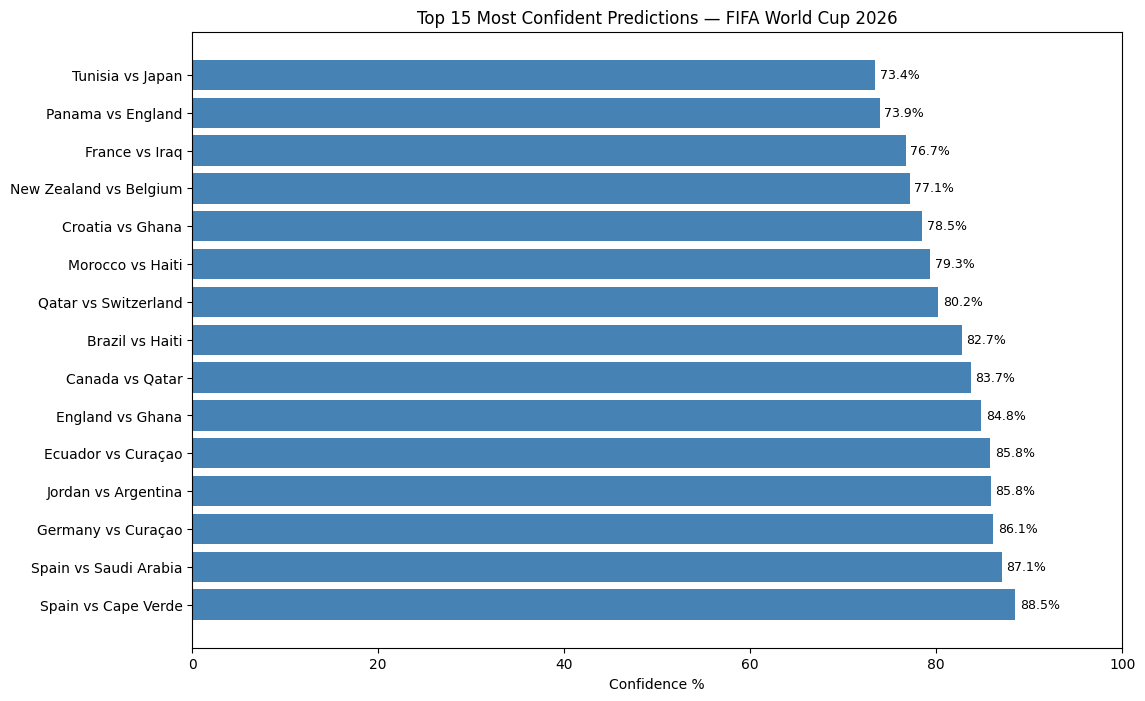

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# Get the highest probability for each match
upcoming_df['max_prob'] = probabilities.max(axis=1) * 100
upcoming_df['predicted_team'] = upcoming_df.apply(
    lambda row: row['home_team'] if row['predicted_result'] == 'H' 
    else (row['away_team'] if row['predicted_result'] == 'A' 
    else 'Draw'), axis=1
)
upcoming_df['match'] = upcoming_df['home_team'] + ' vs ' + upcoming_df['away_team']

# Top 15 most confident
top15 = upcoming_df.nlargest(15, 'max_prob')

plt.figure(figsize=(12, 8))
bars = plt.barh(top15['match'], top15['max_prob'], color='steelblue')
plt.xlabel('Confidence %')
plt.title('Top 15 Most Confident Predictions — FIFA World Cup 2026')
plt.xlim(0, 100)

# Add percentage labels
for bar, val in zip(bars, top15['max_prob']):
    plt.text(val + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{val:.1f}%', va='center', fontsize=9)



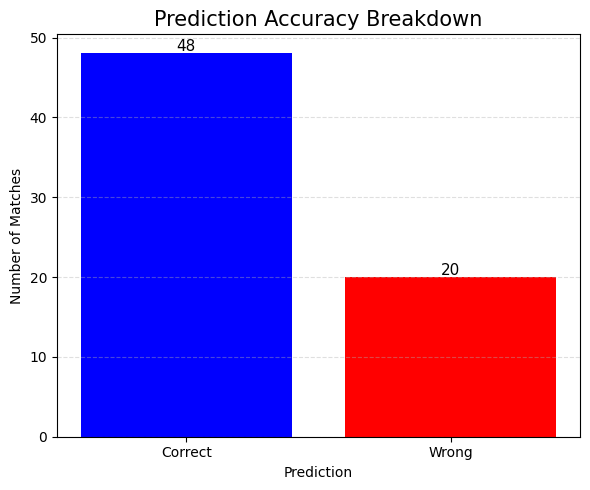

In [49]:


correct = correct
wrong = total - correct

plt.figure(figsize=(6,5))

bars = plt.bar(
    ['Correct', 'Wrong'],
    [correct, wrong],
    color=['blue', 'red']
)

plt.title("Prediction Accuracy Breakdown", fontsize=15)
plt.xlabel("Prediction")
plt.ylabel("Number of Matches")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.3,
             int(height),
             ha='center',
             fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

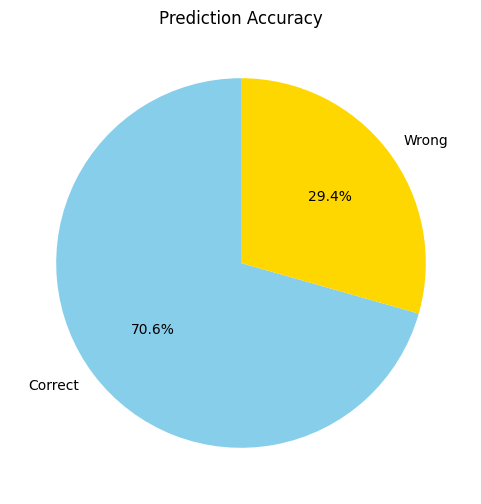

In [50]:
plt.figure(figsize=(6,6))

plt.pie(
    [correct, wrong],
    labels=['Correct', 'Wrong'],
    autopct='%1.1f%%',
    colors=['skyblue', 'gold'],
    startangle=90
)

plt.title("Prediction Accuracy")

plt.show()

In [51]:
wc_teams=pd.unique(
    pd.concat(
        [
            upcoming_df['home_team'],
            upcoming_df['away_team']
        ]
    )
)
    
elo_df = pd.DataFrame(
    list(final_elo.items()),
    columns=["Team", "Elo"]
)
wc_elo=elo_df[elo_df["Team"].isin(wc_teams)].sort_values("Elo",ascending=False)
wc_elo.reset_index(drop=True)


,Team,Elo
0,Argentina,1555.332610
1,Spain,1531.993840
2,France,1475.510504
3,Portugal,1450.506595
4,Brazil,1448.583625
5,England,1446.588444
6,Colombia,1442.104926
7,Germany,1437.066624
8,Japan,1434.329044
9,Morocco,1426.339983


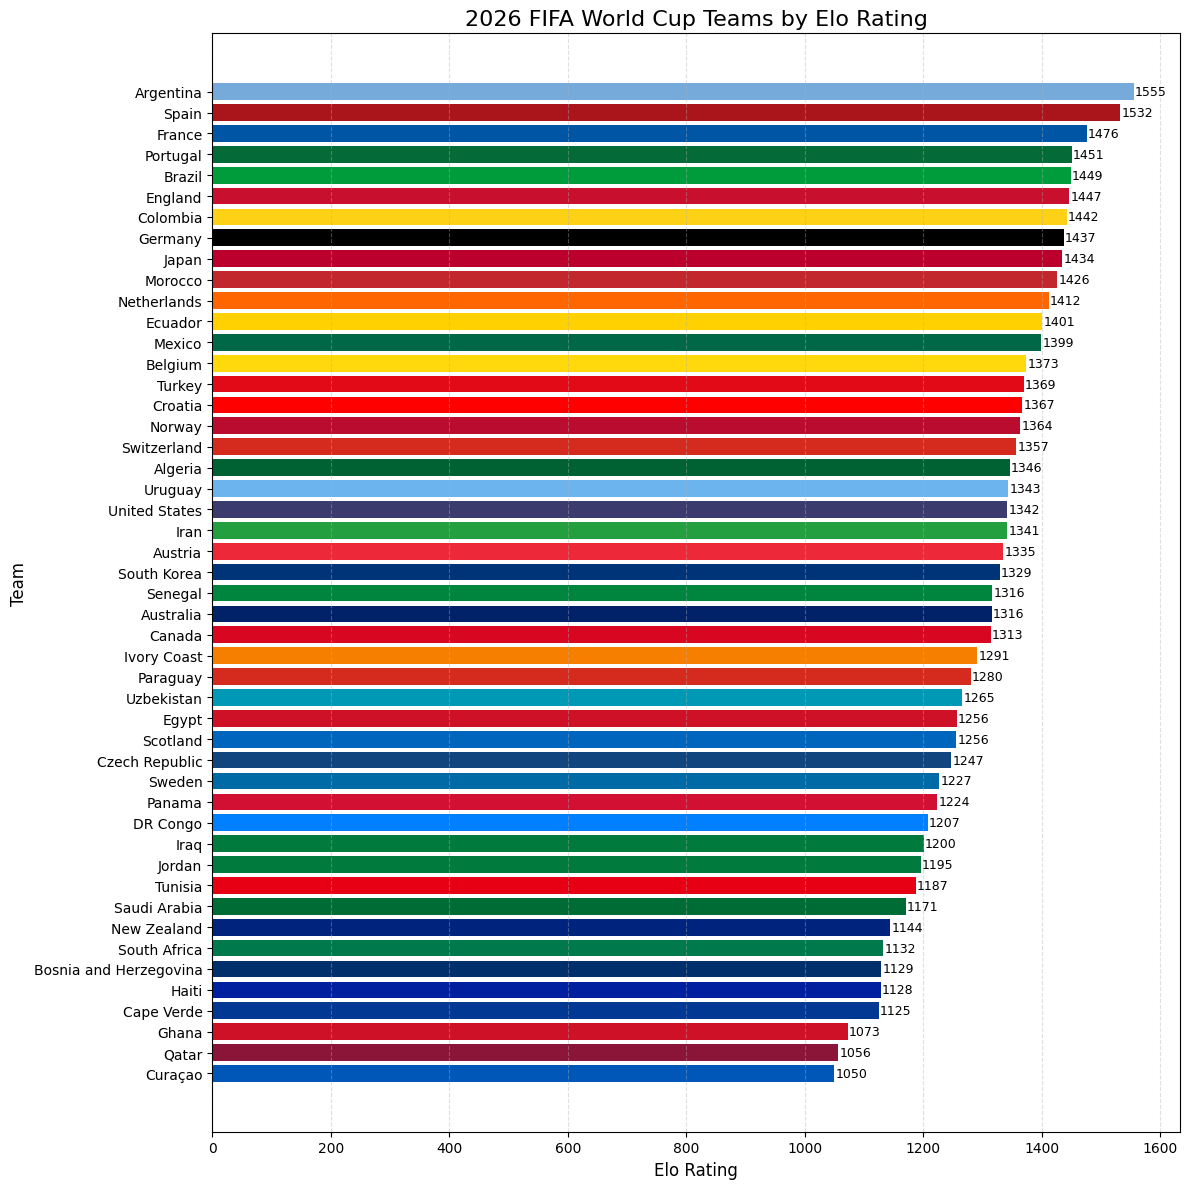

In [ ]:


plt.figure(figsize=(12,12))
country_colors = {
    "Algeria": "#006233",
    "Argentina": "#75AADB",
    "Australia": "#012169",
    "Austria": "#ED2939",
    "Belgium": "#FFD90C",
    "Bosnia and Herzegovina": "#002F6C",
    "Brazil": "#009C3B",
    "Canada": "#D80621",
    "Cape Verde": "#003893",
    "Colombia": "#FCD116",
    "Croatia": "#FF0000",
    "Curaçao": "#0057B8",
    "Czech Republic": "#11457E",
    "DR Congo": "#007FFF",
    "Ecuador": "#FFD100",
    "Egypt": "#CE1126",
    "England": "#C8102E",
    "France": "#0055A4",
    "Germany": "#000000",
    "Ghana": "#CE1126",
    "Haiti": "#00209F",
    "Iran": "#239F40",
    "Iraq": "#007A3D",
    "Ivory Coast": "#F77F00",
    "Japan": "#BC002D",
    "Jordan": "#007A3D",
    "Mexico": "#006847",
    "Morocco": "#C1272D",
    "Netherlands": "#FF6600",
    "New Zealand": "#00247D",
    "Norway": "#BA0C2F",
    "Panama": "#D21034",
    "Paraguay": "#D52B1E",
    "Portugal": "#046A38",
    "Qatar": "#8A1538",
    "Saudi Arabia": "#006C35",
    "Scotland": "#0065BD",
    "Senegal": "#00853F",
    "South Africa": "#007A4D",
    "South Korea": "#003478",
    "Spain": "#AA151B",
    "Sweden": "#006AA7",
    "Switzerland": "#D52B1E",
    "Tunisia": "#E70013",
    "Turkey": "#E30A17",
    "United States": "#3C3B6E",
    "Uruguay": "#6CB4EE",
    "Uzbekistan": "#0099B5"
}
colors = [country_colors[team] for team in wc_elo["Team"]]

bars = plt.barh(
    wc_elo["Team"],
    wc_elo["Elo"],
    color=colors
)

plt.gca().invert_yaxis()

plt.title("2026 FIFA World Cup Teams by Elo Rating", fontsize=16)
plt.xlabel("Elo Rating", fontsize=12)
plt.ylabel("Team", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.4)
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 2,                           # x-position (slightly after the bar)
        bar.get_y() + bar.get_height()/2,    # y-position (middle of the bar)
        f"{width:.0f}",                      # Elo value, rounded to nearest integer
        va="center",
        fontsize=9
    )
plt.tight_layout()

# plt.show()

In [53]:
probabilities = lr_model.predict_proba(X_upcoming_scaled)

upcoming_df["away_win_prob"] = probabilities[:, 0] * 100
upcoming_df["draw_prob"] = probabilities[:, 1] * 100
upcoming_df["home_win_prob"] = probabilities[:, 2] * 100

In [54]:
arg_matches=upcoming_df[(upcoming_df['home_team']=="Argentina") | (upcoming_df["away_team"]=="Argentina")]
arg_matches[
    [
        "home_team",
        "away_team",
        "predicted_result",
        "home_win_prob",
        "draw_prob",
        "away_win_prob"
    ]
]

,home_team,away_team,predicted_result,home_win_prob,draw_prob,away_win_prob
14,Argentina,Algeria,H,68.446510,19.238168,12.315323
38,Argentina,Austria,H,69.811064,18.498788,11.690148
63,Jordan,Argentina,A,3.503818,10.652334,85.843848


In [55]:
def get_team_matches(team):
    team_matches=upcoming_df[(upcoming_df['home_team']==team) | (upcoming_df["away_team"]==team)]
    return team_matches[

    [
        "home_team",
        "away_team",
        "predicted_result",
        "home_win_prob",
        "draw_prob",
        "away_win_prob"
    ]
]
    
get_team_matches("Spain")

,home_team,away_team,predicted_result,home_win_prob,draw_prob,away_win_prob
10,Spain,Cape Verde,H,88.507146,8.566921,2.925932
34,Spain,Saudi Arabia,H,87.052614,9.482334,3.465051
59,Uruguay,Spain,A,11.227614,18.961137,69.811248


In [56]:


def plot_team_predictions(team_name):

    team_matches = get_team_matches(team_name)

    for _, row in team_matches.iterrows():

        # Labels
        labels = [
            f"{row['home_team']} Win",
            "Draw",
            f"{row['away_team']} Win"
        ]

        # Probabilities
        probs = [
            row["home_win_prob"],
            row["draw_prob"],
            row["away_win_prob"]
        ]

        # Colors
        colors = [
        country_colors[row["home_team"]],
        "gray",
        country_colors[row["away_team"]]
        ]

        plt.figure(figsize=(8,3.5))

        bars = plt.barh(
            labels,
            probs,
            color=colors
        )

        plt.xlim(0,100)

        plt.xlabel("Probability (%)")
        plt.title(f"{row['home_team']} vs {row['away_team']}")

        # Display probability values
        for bar in bars:

            width = bar.get_width()

            plt.text(
                width + 1,
                bar.get_y() + bar.get_height()/2,
                f"{width:.1f}%",
                va="center",
                fontsize=10,
                fontweight="bold"
            )

        plt.grid(axis="x", linestyle="--", alpha=0.4)

        plt.tight_layout()
        plt.show()

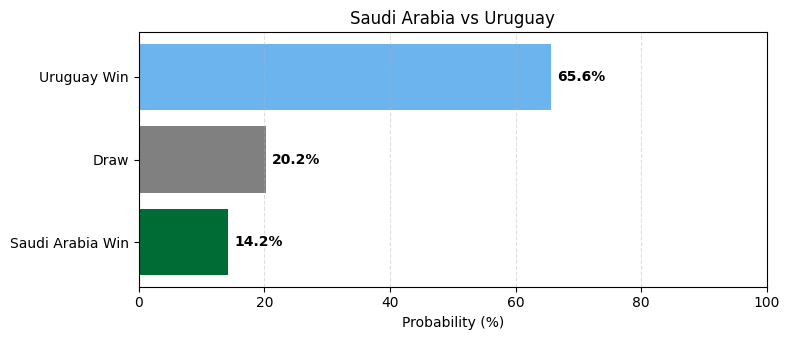

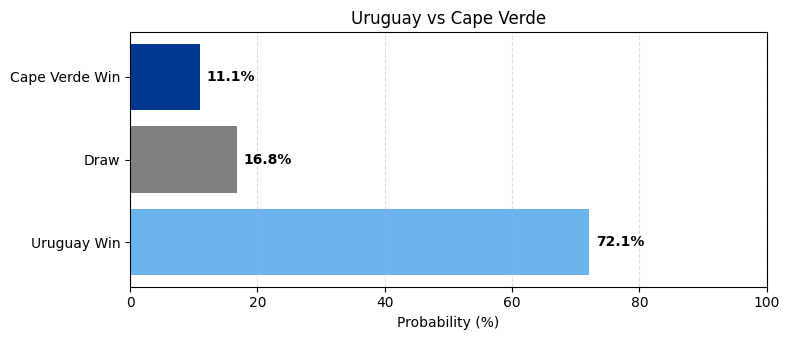

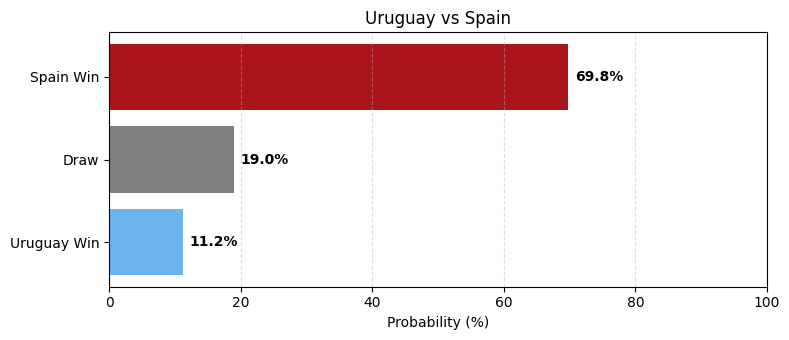

In [63]:
plot_team_predictions("Uruguay")

In [68]:
r32_fixtures = pd.DataFrame([
    {'home_team': 'South Africa', 'away_team': 'Canada', 'date': '2026-06-28', 'neutral': 1},
    {'home_team': 'Brazil', 'away_team': 'Japan', 'date': '2026-06-29', 'neutral': 1},
    {'home_team': 'Germany', 'away_team': 'Paraguay', 'date': '2026-06-29', 'neutral': 1},
    {'home_team': 'Netherlands', 'away_team': 'Morocco', 'date': '2026-06-30', 'neutral': 1},
    {'home_team': 'Ivory Coast', 'away_team': 'Norway', 'date': '2026-06-30', 'neutral': 1},
    {'home_team': 'France', 'away_team': 'Sweden', 'date': '2026-06-30', 'neutral': 1},
    {'home_team': 'Mexico', 'away_team': 'Ecuador', 'date': '2026-07-01', 'neutral': 0},
    {'home_team': 'England', 'away_team': 'DR Congo', 'date': '2026-07-01', 'neutral': 1},
    {'home_team': 'Belgium', 'away_team': 'Senegal', 'date': '2026-07-02', 'neutral': 1},
    {'home_team': 'United States', 'away_team': 'Bosnia and Herzegovina', 'date': '2026-07-02', 'neutral': 0},
    {'home_team': 'Spain', 'away_team': 'Austria', 'date': '2026-07-03', 'neutral': 1},
    {'home_team': 'Portugal', 'away_team': 'Croatia', 'date': '2026-07-03', 'neutral': 1},
    {'home_team': 'Switzerland', 'away_team': 'Algeria', 'date': '2026-07-03', 'neutral': 1},
    {'home_team': 'Australia', 'away_team': 'Egypt', 'date': '2026-07-03', 'neutral': 1},
    {'home_team': 'Argentina', 'away_team': 'Cape Verde', 'date': '2026-07-03', 'neutral': 1},
    {'home_team': 'Colombia', 'away_team': 'Ghana', 'date': '2026-07-03', 'neutral': 1},
])

r32_fixtures['date'] = pd.to_datetime(r32_fixtures['date'])
r32_fixtures['tournament'] = 'FIFA World Cup'
r32_fixtures['tournament_weight'] = 5

print(r32_fixtures.shape)
print("R32 fixtures loaded!")
r32_fixtures

(16, 6)
R32 fixtures loaded!


,home_team,away_team,date,neutral,tournament,tournament_weight
0,South Africa,Canada,2026-06-28,1,FIFA World Cup,5
1,Brazil,Japan,2026-06-29,1,FIFA World Cup,5
2,Germany,Paraguay,2026-06-29,1,FIFA World Cup,5
3,Netherlands,Morocco,2026-06-30,1,FIFA World Cup,5
4,Ivory Coast,Norway,2026-06-30,1,FIFA World Cup,5
5,France,Sweden,2026-06-30,1,FIFA World Cup,5
6,Mexico,Ecuador,2026-07-01,0,FIFA World Cup,5
7,England,DR Congo,2026-07-01,1,FIFA World Cup,5
8,Belgium,Senegal,2026-07-02,1,FIFA World Cup,5
9,United States,Bosnia and Herzegovina,2026-07-02,0,FIFA World Cup,5


In [67]:
# # Get all 2026 WC group stage matches from upcoming_df
# upcoming_matches = set(
#     upcoming_df['home_team'] + ' vs ' + upcoming_df['away_team']
# )
# print(f"We have: {len(upcoming_matches)} matches")
# print("\nOur matches:")
# for m in sorted(upcoming_matches):
#     print(m)

In [66]:
# # Find 2026 World Cup matches that already have scores (in historical_df)
# wc_2026_played = historical_df[
#     (historical_df['tournament'] == 'FIFA World Cup') &
#     (historical_df['date'] >= '2026-06-01')
# ]

# print(f"WC 2026 matches already in historical_df: {len(wc_2026_played)}")
# print(wc_2026_played[['date', 'home_team', 'away_team', 'home_score', 'away_score']].to_string())

In [96]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost needs numeric labels, not H/A/D strings
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_scaled, y_train_encoded)
xgb_pred = xgb_model.predict(X_test_scaled)
xgb_accuracy = (xgb_pred == y_test_encoded).mean() * 100
print(f"XGBoost: {round(xgb_accuracy, 2)}%")

XGBoost: 59.58%


NameError: name 'wc_2026_all' is not defined